In [1]:
#Bibliotecas
import pandas as pd
import polars as pl
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import re
import math

In [2]:
caminho_arquivo = "tratados_3det/photon/photon3.16E15"

def processar_arquivo(nome_arquivo):
    # Listas para armazenar as detecções por tipo de partícula e por detector
    positrons = {"TRIG1": [], "TRIG2": [], "TRIG3": []}
    electrons = {"TRIG1": [], "TRIG2": [], "TRIG3": []}
    muons_plus = {"TRIG1": [], "TRIG2": [], "TRIG3": []}
    muons_minus = {"TRIG1": [], "TRIG2": [], "TRIG3": []}

    # Listas para totais por detector
    total_por_detector = {"TRIG1": [], "TRIG2": [], "TRIG3": []}

    # Listas para somas de elétrons+pósitrons e múons+/-
    soma_electrons_positrons = {"TRIG1": [], "TRIG2": [], "TRIG3": []}
    soma_muons_plus_minus = {"TRIG1": [], "TRIG2": [], "TRIG3": []}

    # Abrir e ler o arquivo
    with open(nome_arquivo, 'r') as arquivo:
        for linha in arquivo:
            linha = linha.strip()

            # Processar apenas linhas que começam com TRIG
            if linha.startswith("TRIG"):
                partes = linha.split()
                detector = partes[0]  # TRIG1, TRIG2, TRIG3

                # Valores das partículas
                pos = int(partes[1])  # Pósitrons
                ele = int(partes[2])  # Elétrons
                mu_p = int(partes[3])  # Múons+
                mu_m = int(partes[4])  # Múons-

                # Adicionar os valores às listas correspondentes
                positrons[detector].append(pos)
                electrons[detector].append(ele)
                muons_plus[detector].append(mu_p)
                muons_minus[detector].append(mu_m)

                # Calcular totais
                total = pos + ele + mu_p + mu_m
                total_por_detector[detector].append(total)

                # Calcular somas
                soma_electrons_positrons[detector].append(pos + ele)
                soma_muons_plus_minus[detector].append(mu_p + mu_m)

    # Retornar os dados processados
    return {
        "positrons": positrons,
        "electrons": electrons,
        "muons_plus": muons_plus,
        "muons_minus": muons_minus,
        "total_por_detector": total_por_detector,
        "soma_electrons_positrons": soma_electrons_positrons,
        "soma_muons_plus_minus": soma_muons_plus_minus
    }

# Função principal
def main():
    
    dados = processar_arquivo(caminho_arquivo)

    # Alguns testes
    print("Detecções de pósitrons no TRIG1:", dados["positrons"]["TRIG1"])
    print("Total de partículas no TRIG2:", dados["total_por_detector"]["TRIG2"])
    print("Soma de elétrons e pósitrons no TRIG3:", dados["soma_electrons_positrons"]["TRIG3"])

    return dados



# Executar o programa
if __name__ == "__main__":
    dados_processados = main()


Detecções de pósitrons no TRIG1: [5, 95, 23, 78, 14, 256, 0, 0, 29, 0, 14, 21, 1, 52, 0, 0, 5, 0, 3, 193, 16, 44, 63, 79, 89, 280, 1, 4, 68, 31, 24, 12, 0, 0, 72, 289, 0, 0, 64, 1, 42, 37, 0, 32, 0, 9, 1, 0, 21, 147, 0, 4, 0, 0, 1, 520, 452, 0, 347, 42, 68, 99, 1, 1, 41, 45, 106, 0, 0, 4, 7, 206, 5, 0, 273, 496, 0, 18, 0, 15, 25, 92, 27, 24, 16, 2, 192, 0, 0, 33, 158, 334, 73, 1, 0, 65, 6, 0, 129, 0, 39, 240, 38, 33, 6, 46, 0, 0, 16, 99, 41, 55, 0, 0, 311, 296, 15, 12, 272, 0, 5, 1, 44, 0, 229, 1, 0, 2, 0, 1, 43, 155, 312, 0, 183, 0, 4, 2, 121, 0, 47, 45, 371, 1, 5, 0, 1, 52, 62, 0, 306, 103, 150, 0, 0, 46, 0, 0, 0, 71, 1, 43, 207, 9, 0, 104, 4, 6, 0, 10, 40, 54, 140, 71, 0, 0, 56, 21, 7, 41, 536, 9, 89, 0, 165, 1, 0, 5, 258, 0, 410, 0, 3, 146, 96, 1, 0, 0, 34, 17, 3, 0, 93, 0, 351, 0, 0, 173, 0, 9, 2, 326, 28, 0, 0, 7, 12, 0, 0, 0, 0, 111, 0, 228, 2, 137, 25, 0, 319, 152, 0, 42, 27, 1, 65, 6, 23, 4, 3, 160, 10, 10, 18, 42, 242, 32, 486, 0, 183, 345, 22, 0, 0, 55, 200, 27, 33, 0, 21, 2

In [3]:
def formatar_string(s):

    nome_arquivo = s.split('/')[-1]
   
    match = re.match(r'([a-zA-Z]+)([0-9]+(?:\.[0-9]+)?[Ee][0-9]+)', nome_arquivo)

    if match:
        
        palavra = match.group(1).capitalize()
        numero = match.group(2)

        return f'{palavra} {numero}'
    else:
        return nome_arquivo

name = formatar_string(caminho_arquivo)
name

'Photon 3.16E15'

In [4]:
# Posição dos tanques
x1 = [0,346]
x2 = [-400,-346]
x3 = [400,-346]

# Distância dos tanques em relação ao centro
r1 = (x1[0]**2+x1[1]**2)**0.5
r2 = (x2[0]**2+x2[1]**2)**0.5
r3 = (x3[0]**2+x3[1]**2)**0.5


# Total de partículas em cada tanque
trig1_total = dados_processados['total_por_detector']['TRIG1']
trig2_total = dados_processados['total_por_detector']['TRIG2']
trig3_total = dados_processados['total_por_detector']['TRIG3']

print(trig1_total,'\n',
      trig2_total,'\n',
      trig3_total)

[16, 223, 56, 205, 38, 614, 0, 0, 82, 0, 26, 48, 2, 123, 0, 0, 14, 3, 9, 466, 35, 119, 141, 190, 224, 662, 5, 6, 180, 75, 55, 28, 0, 0, 165, 726, 0, 3, 173, 1, 91, 101, 0, 75, 0, 24, 1, 1, 47, 331, 0, 12, 0, 0, 2, 1183, 1099, 1, 860, 103, 172, 216, 6, 1, 93, 124, 228, 0, 2, 13, 15, 522, 16, 0, 642, 1202, 0, 44, 0, 27, 46, 199, 57, 74, 34, 8, 440, 0, 0, 89, 364, 808, 167, 2, 0, 153, 10, 0, 285, 0, 89, 563, 92, 83, 14, 107, 0, 0, 34, 241, 122, 142, 1, 1, 698, 689, 42, 25, 671, 0, 12, 4, 107, 0, 595, 1, 0, 2, 0, 1, 113, 391, 737, 0, 449, 2, 5, 4, 326, 0, 111, 98, 855, 1, 8, 0, 4, 114, 128, 0, 761, 206, 336, 0, 0, 123, 0, 2, 0, 149, 3, 108, 474, 24, 0, 235, 18, 9, 1, 29, 104, 154, 325, 185, 0, 0, 134, 55, 19, 74, 1328, 18, 212, 1, 368, 3, 1, 15, 623, 1, 895, 0, 4, 340, 193, 3, 0, 0, 79, 31, 6, 0, 215, 0, 846, 0, 1, 405, 0, 26, 4, 710, 63, 0, 0, 12, 26, 0, 0, 0, 0, 272, 0, 532, 3, 316, 53, 0, 774, 369, 0, 137, 68, 1, 140, 17, 46, 7, 4, 412, 23, 25, 39, 85, 571, 76, 1160, 0, 477, 841, 49, 0,

In [5]:
# Triangulação

triangulacao = [
    (a, b, c) for a, b, c in zip(trig1_total, trig2_total, trig3_total) if a != 0 and b != 0 and c != 0
]

trig1, trig2, trig3 = zip(*triangulacao) if triangulacao else ([], [], [])


print(trig1,'\n',
      trig2,'\n',
      trig3)

(16, 223, 56, 205, 38, 614, 82, 26, 48, 2, 123, 14, 3, 9, 466, 35, 119, 141, 190, 224, 662, 5, 6, 180, 75, 55, 28, 165, 726, 173, 1, 91, 101, 75, 24, 47, 331, 12, 2, 1183, 1099, 860, 103, 172, 216, 6, 93, 124, 228, 13, 15, 522, 16, 642, 1202, 44, 27, 46, 199, 57, 74, 34, 8, 440, 89, 364, 808, 167, 153, 10, 285, 89, 563, 92, 83, 14, 107, 34, 241, 122, 142, 698, 689, 42, 25, 671, 12, 4, 107, 595, 1, 2, 113, 391, 737, 449, 2, 4, 326, 111, 98, 855, 1, 8, 114, 128, 761, 206, 336, 123, 149, 108, 474, 24, 235, 18, 9, 29, 104, 154, 325, 185, 134, 55, 19, 74, 1328, 18, 212, 368, 3, 15, 623, 895, 4, 340, 193, 3, 79, 31, 6, 215, 846, 405, 26, 710, 63, 12, 26, 272, 532, 3, 316, 53, 774, 369, 137, 68, 140, 17, 46, 412, 23, 25, 39, 85, 571, 76, 1160, 477, 841, 49, 159, 501, 49, 91, 71, 59, 376, 3, 290, 996, 361, 14, 71, 230, 27, 882, 731, 94, 79, 256, 546, 117, 22, 719, 39, 168, 210, 351, 24, 127, 613, 108, 226, 233, 4, 205, 15, 225, 7, 148, 8, 14, 934, 161, 98, 24) 
 (11, 145, 32, 125, 30, 472, 54,

In [6]:
len(trig1)

218

In [7]:
import statistics
statistics.mean(trig1)
#np.mean(trig3)

226.954128440367

In [8]:
x_b = []
y_b = []

for i in range(len(trig1)):
        numerator = (trig1[i]*x1[0]+trig2[i]*x2[0]+trig3[i]*x3[0])
        demoninator = (trig1[i]+trig2[i]+trig3[i])
        numerator1 = (trig1[i]*x1[1]+trig2[i]*x2[1]+trig3[i]*x3[1])

        if demoninator == 0:
                x_b.append(0)
                y_b.append(0)
        else:
                x_b.append(numerator/demoninator)
                y_b.append(numerator1/demoninator)


In [9]:
data = {
    'x_b':x_b,
    'y_b':y_b,
    'trig1':trig1,
    'trig2':trig2,
    'trig3':trig3
}

df = pl.DataFrame(data, strict=False)

df = df.with_columns(
    [
        ((df['x_b']**2+df['y_b']**2)**0.5).alias('r_b'),
        (pl.col('trig1')/(math.pi*65**2)).alias('rho1'),
        (pl.col('trig2')/(math.pi*65**2)).alias('rho2'),
        (pl.col('trig3')/(math.pi*65**2)).alias('rho3')
    ]
)

df = df.with_columns(
    [
        (((x1[0]-df['x_b'])**2 + (x1[1]-df['y_b'])**2)**0.5).alias('r1_b'),
        (((x2[0]-df['x_b'])**2 + (x2[1]-df['y_b'])**2)**0.5).alias('r2_b'),
        (((x3[0]-df['x_b'])**2 + (x3[1]-df['y_b'])**2)**0.5).alias('r3_b'),
    ]
)


df
#df2 = df.mean()
#df2

x_b,y_b,trig1,trig2,trig3,r_b,rho1,rho2,rho3,r1_b,r2_b,r3_b
f64,f64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64
0.0,-54.631579,16,11,11,54.631579,0.001205,0.000829,0.000829,400.631579,494.869232,494.869232
17.164179,-58.097015,223,145,168,60.57947,0.016801,0.010924,0.012657,404.461378,506.866926,479.01085
33.587786,-50.183206,56,32,43,60.386203,0.004219,0.002411,0.00324,397.604417,524.886601,470.91983
-2.654867,-32.150442,205,125,122,32.259871,0.015445,0.009417,0.009191,378.159762,506.344447,510.521779
-35.555556,-53.822222,38,30,22,64.50604,0.002863,0.00226,0.001657,401.400058,467.105563,524.477355
…,…,…,…,…,…,…,…,…,…,…,…
-12.121212,-52.424242,14,10,9,53.807295,0.001055,0.000753,0.000678,398.608581,486.453163,505.994683
-0.745573,-44.821994,934,608,604,44.828195,0.070367,0.045806,0.045505,390.822706,500.112276,501.303506
-13.521127,-32.16338,161,103,91,34.889882,0.01213,0.00776,0.006856,378.405025,497.854741,519.127293


In [10]:
def calcular_s(rho_i, rho_j, r_i, r_j):
    log_rho_diff = pl.col(rho_i).log() - pl.col(rho_j).log()
    log_r_diff = pl.col(r_i).abs().log() - pl.col(r_j).abs().log()

    s_expr = pl.when((log_rho_diff == 0) & (log_r_diff == 0)) \
              .then(0) \
              .otherwise(-log_rho_diff / log_r_diff)
    
    return s_expr

df = df.with_columns([
    calcular_s("rho1", "rho2", "r1_b", "r2_b").alias("s1"),
    calcular_s("rho2", "rho3", "r2_b", "r3_b").alias("s2"),
    calcular_s("rho1", "rho3", "r1_b", "r3_b").alias("s3"),
])

df = df.with_columns(
    df.select(["s1", "s2", "s3"]).mean_horizontal().alias("s_mean")
)
df

x_b,y_b,trig1,trig2,trig3,r_b,rho1,rho2,rho3,r1_b,r2_b,r3_b,s1,s2,s3,s_mean
f64,f64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0.0,-54.631579,16,11,11,54.631579,0.001205,0.000829,0.000829,400.631579,494.869232,494.869232,1.773686,0.0,1.773686,1.182457
17.164179,-58.097015,223,145,168,60.57947,0.016801,0.010924,0.012657,404.461378,506.866926,479.01085,1.90719,2.604681,1.674131,2.062001
33.587786,-50.183206,56,32,43,60.386203,0.004219,0.002411,0.00324,397.604417,524.886601,470.91983,2.015002,2.723314,1.5609,2.099739
-2.654867,-32.150442,205,125,122,32.259871,0.015445,0.009417,0.009191,378.159762,506.344447,510.521779,1.694743,2.956705,1.729291,2.126913
-35.555556,-53.822222,38,30,22,64.50604,0.002863,0.00226,0.001657,401.400058,467.105563,524.477355,1.559327,2.677281,2.043584,2.093397
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
-12.121212,-52.424242,14,10,9,53.807295,0.001055,0.000753,0.000678,398.608581,486.453163,505.994683,1.689451,2.675107,1.852189,2.072249
-0.745573,-44.821994,934,608,604,44.828195,0.070367,0.045806,0.045505,390.822706,500.112276,501.303506,1.741033,2.774453,1.750909,2.088798
-13.521127,-32.16338,161,103,91,34.889882,0.01213,0.00776,0.006856,378.405025,497.854741,519.127293,1.628163,2.960497,1.804471,2.131044


In [11]:
r_0 = 7800

# Função para o ajuste
def model(r, C, s, r0):
    return C * (r**-s) / (r0**2)

# Função para ajustar e encontrar C
def find_C(row):
    
    rho_values = np.array([row["rho1"], row["rho2"], row["rho3"]])
    r_values = np.array([row["r1_b"], row["r2_b"], row["r3_b"]])
    s = row["s_mean"]
    
    popt, _ = curve_fit(
        lambda r, C: model(r, C, s, r_0),  
        r_values,                          
        rho_values,                        
        p0=[10000.0]   # Valor inicial para C
    )
    
    return popt[0]

df = df.with_columns(
    pl.struct(["rho1", "rho2", "rho3", "r1_b", "r2_b", "r3_b", "s_mean"])
    .map_elements(lambda row: find_C(row), return_dtype= float)
    .alias("C_optimized")
)

df = df.with_columns([
    (pl.col("rho1") * r_0**2 * pl.col("r1_b")**pl.col("s_mean")).alias("C1"),
    (pl.col("rho2") * r_0**2 * pl.col("r2_b")**pl.col("s_mean")).alias("C2"),
    (pl.col("rho3") * r_0**2 * pl.col("r3_b")**pl.col("s_mean")).alias("C3")
])

df = df.with_columns(
    ((pl.col("C1") + pl.col("C2") + pl.col("C3")) / 3).alias("C_mean")
)

df

C:\Users\Lucas\AppData\Local\Temp\ipykernel_7400\563486506.py:14: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(


x_b,y_b,trig1,trig2,trig3,r_b,rho1,rho2,rho3,r1_b,r2_b,r3_b,s1,s2,s3,s_mean,C_optimized,C1,C2,C3,C_mean
f64,f64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0.0,-54.631579,16,11,11,54.631579,0.001205,0.000829,0.000829,400.631579,494.869232,494.869232,1.773686,0.0,1.773686,1.182457,8.2049e7,8.7694e7,7.7397e7,7.7397e7,8.0829e7
17.164179,-58.097015,223,145,168,60.57947,0.016801,0.010924,0.012657,404.461378,506.866926,479.01085,1.90719,2.604681,1.674131,2.062001,2.4873e11,2.4261e11,2.5123e11,2.5906e11,2.5096e11
33.587786,-50.183206,56,32,43,60.386203,0.004219,0.002411,0.00324,397.604417,524.886601,470.91983,2.015002,2.723314,1.5609,2.099739,7.5939e10,7.3717e10,7.5473e10,8.0755e10,7.6648e10
-2.654867,-32.150442,205,125,122,32.259871,0.015445,0.009417,0.009191,378.159762,506.344447,510.521779,1.694743,2.956705,1.729291,2.126913,2.9891e11,2.8540e11,3.2378e11,3.2158e11,3.1025e11
-35.555556,-53.822222,38,30,22,64.50604,0.002863,0.00226,0.001657,401.400058,467.105563,524.477355,1.559327,2.677281,2.043584,2.093397,5.0426e10,4.9127e10,5.3270e10,4.9786e10,5.0727e10
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
-12.121212,-52.424242,14,10,9,53.807295,0.001055,0.000753,0.000678,398.608581,486.453163,505.994683,1.689451,2.675107,1.852189,2.072249,1.6191e10,1.5715e10,1.6960e10,1.6562e10,1.6413e10
-0.745573,-44.821994,934,608,604,44.828195,0.070367,0.045806,0.045505,390.822706,500.112276,501.303506,1.741033,2.774453,1.750909,2.088798,1.1518e12,1.1109e12,1.2104e12,1.2084e12,1.1766e12
-13.521127,-32.16338,161,103,91,34.889882,0.01213,0.00776,0.006856,378.405025,497.854741,519.127293,1.628163,2.960497,1.804471,2.131044,2.4090e11,2.3003e11,2.6405e11,2.5505e11,2.4971e11


In [12]:
# Modelagem NKG
#def model(r, C, s):
#    r0 = 7800
#    return C/(r0^2)*(r/r0)**(s-2)*(1+r/r0)**(s-4.5)

def model(r, C, s):
     r0 = 7800
     return C/(r0^2)*(r)**(s-2)

parameters = []

x_cols = ['r1_b', 'r2_b', 'r3_b']  
y_cols = ['rho1', 'rho2', 'rho3']

x = df.select(x_cols).to_numpy()  
y = df.select(y_cols).to_numpy()

#inferior_bounds = [-np.inf, 1]
#superior_bounds = [np.inf, 2.2]

#for i in range(len(x)):
#    print(f"Linha {i}: x = {x[i]}, y = {y[i]}")

for i in range(len(x)):
    r = x[i]  
    rho = y[i]  
    try:
        popt, _ = curve_fit(model, r, rho, bounds= ([-np.inf, 1.2], [np.inf, 2.2]))
        parameters.append(popt)
    except RuntimeError:
        parameters.append([np.nan, np.nan])


parameters_df = pd.DataFrame(parameters, columns=["C", "s"])

parameters_df


,C,s
0,3.535098,2.120285
1,14250.300334,1.200204
2,3487.125746,1.200403
3,12072.325794,1.200000
4,2390.903989,1.200711
...,...,...
213,4.229689,2.067811
214,57200.629656,1.200012
215,9340.233240,1.202401
216,5722.351874,1.201940


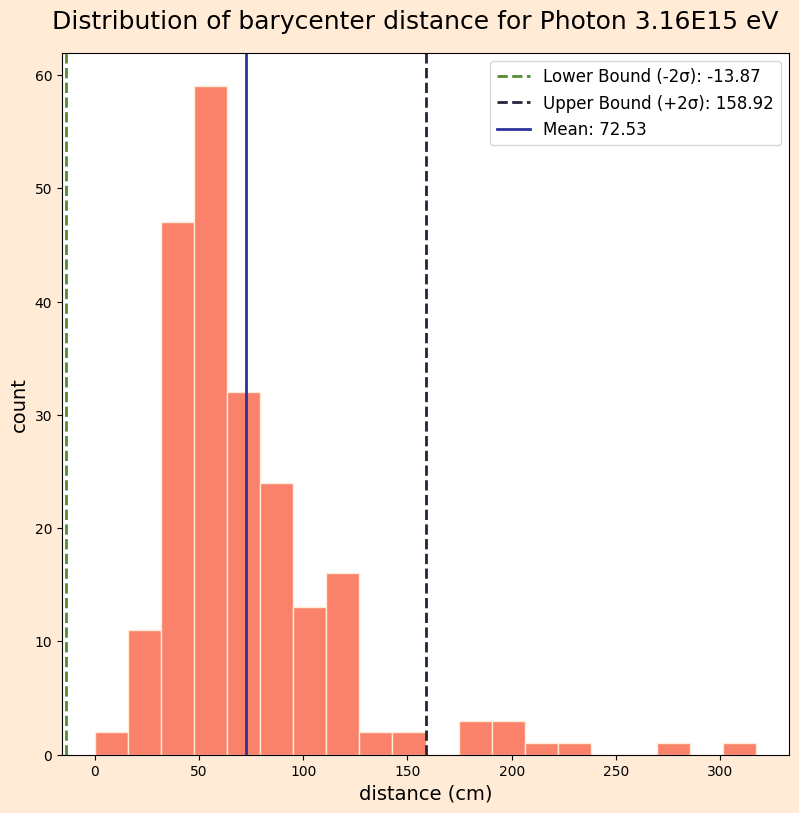

In [13]:
fig, ax = plt.subplots(1, 1, figsize = (8, 8), facecolor = '#FFEBD6')
fig.suptitle('Distribution of barycenter distance for ' + str(name) + ' eV', size = 18)
fig.tight_layout()

# Calcula a média e o desvio padrão dos dados
mean = df['r_b'].mean()
std = df['r_b'].std()

# Determina os limites de 2 sigma
lower_bound = mean - 2 * std
upper_bound = mean + 2 * std

sns.histplot(df, x = df['r_b'], ax = ax, color = '#F95738', edgecolor = '#FFEBD6', bins = 20)

# Adiciona linhas verticais para os limites de 2 sigma
ax.axvline(lower_bound, color='#548C2F', linestyle='--', linewidth=2, label=f'Lower Bound (-2σ): {lower_bound:.2f}')
ax.axvline(upper_bound, color='#27213C', linestyle='--', linewidth=2, label=f'Upper Bound (+2σ): {upper_bound:.2f}')
ax.axvline(mean, color='#29339B', linestyle='-', linewidth=2, label=f'Mean: {mean:.2f}')

# Personaliza o eixo e a legenda
ax.set_xlabel('distance (cm)', size=14)
ax.set_ylabel('count', size=14)
ax.legend(loc='upper right', fontsize=12)
#plt.savefig('plots/' + name.split(' ')[0].lower() + '/barycenter_' + caminho_arquivo.split('/')[-1] + '.png', bbox_inches = 'tight')

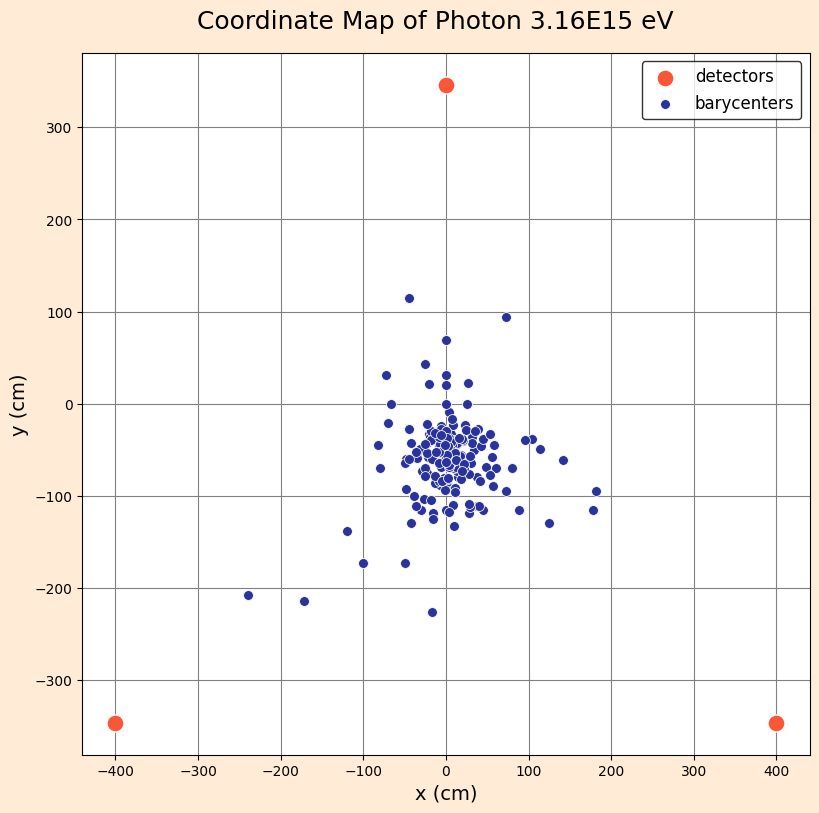

In [14]:
fig, ax = plt.subplots(1, 1, figsize = (8, 8), facecolor = '#FFEBD6')
fig.suptitle('Coordinate Map of ' + str(name) + ' eV', size = 18)
fig.tight_layout()
ax.set_axisbelow(True)
ax.yaxis.grid(color='gray', linestyle='-')
ax.xaxis.grid(color='gray', linestyle='-')

sns.scatterplot(x = [x1[0],x2[0],x3[0]], y = [x1[1],x2[1],x3[1]], ax = ax, color = '#F95738', s = 150)
sns.scatterplot(x = df['x_b'], y = df['y_b'], ax = ax, color = '#29339B',s = 50)

ax.set_xlabel('x (cm)', size = 14)
ax.set_ylabel('y (cm)', size = 14)


ax.legend(['detectors', 'barycenters'], edgecolor = 'black', fontsize = 12, loc = 1)

#plt.savefig('plots/' + name.split(' ')[0].lower() +'/map_'+ caminho_arquivo.split('/')[-1] + '.png',bbox_inches = 'tight')

In [15]:
# Plot dos tanques
#fig, ax = plt.subplots(1, 1, figsize = (8, 8), facecolor = '#FFEBD6')
#fig.suptitle('Coordinate Map of Detectors', size = 18)
#fig.tight_layout()
#ax.set_axisbelow(True)
#ax.yaxis.grid(color='gray', linestyle='-')
#ax.xaxis.grid(color='gray', linestyle='-')
#
#sns.scatterplot(x = [x1[0],x2[0],x3[0]], y = [x1[1],x2[1],x3[1]], ax = ax, color = '#F95738', s = 150)
#
#ax.set_xlabel('x (cm)', size = 14)
#ax.set_ylabel('y (cm)', size = 14)
#
#
#ax.legend(['detectors'], edgecolor = 'black', fontsize = 12, loc = 1)

[1.70432693e-13 5.81146496e-02]
[4.649232   5.28145315 5.91446613 6.54668729]


C:\Users\Lucas\AppData\Local\Temp\ipykernel_7400\577473421.py:24: RuntimeWarning: invalid value encountered in log10
  return np.log10(k*x**p)
C:\Users\Lucas\AppData\Local\Temp\ipykernel_7400\577473421.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'


logC,logE_S,logE_R,error (%)
f64,f64,f64,f64
4.602278,14.0,13.962889,0.265077
5.357554,14.499687,14.559835,0.414819
5.90309,15.0,14.991009,0.059942
6.528917,15.499687,15.485642,0.090617


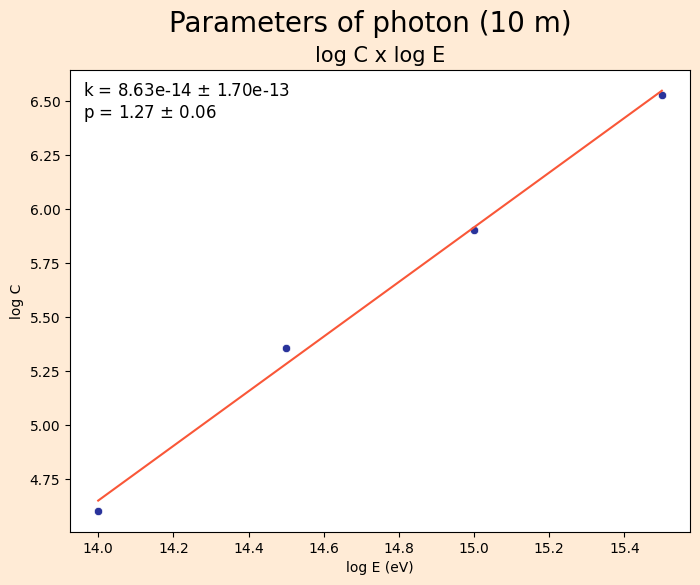

In [17]:
# Fit do fóton
from scipy.optimize import curve_fit

C = [4.00201e+04, 2.278e+05, 8E5, 3.38e+06]
E = [1E14, 3.16E14, 1E15, 3.16E15]

logC = np.log10(C)
logE = np.log10(E)


fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
fig.suptitle('Parameters of photon (10 m)', size = 20)
#fig.tight_layout()


ax.set_title('log C x log E', size = 15)
ax.set_xlabel('log E (eV)')
ax.set_ylabel('log C')
ax.set_facecolor('white')


#Fit
def power(x, k, p):
    return np.log10(k*x**p)

initial_guess = [1,1]

coefficients_photon, cov = curve_fit(power, E, np.log10(C), p0=initial_guess)

inc = np.sqrt(np.diag(cov))
print(np.sqrt(np.diag(cov)))

print(power(E,*coefficients_photon))

ax.plot(logE, power(E,*coefficients_photon), color = '#F95738')
sns.scatterplot(x = logE, y = logC, color = '#29339B', ax = ax)

ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'
          .format(coefficients_photon[0],inc[0],coefficients_photon[1],inc[1]),
          title_fontsize = 12,facecolor = 'white', frameon = False)


logE_0_array = ((np.log10(C/coefficients_photon[0]))/coefficients_photon[1])

logE_0 = logE_0_array.tolist()

data = {
    'logC':logC,
    'logE_S':logE,
    'logE_R':logE_0
}

df_photon = pl.DataFrame(data)

df_photon = df_photon.with_columns(
        abs((((pl.col('logE_R')-pl.col('logE_S'))/pl.col('logE_S'))*100)).alias('error (%)')
)
df_photon

In [18]:
k_photon = coefficients_photon[0] 
p_photon = coefficients_photon[1] 
#c_photon = parameters_df['C'] 
c_photon = df['C_optimized']
E_photon = []
E_real = float(name.split(' ')[1])

erro_relativo = []
erro_absoluto = []

for i in range(len(c_photon)):
    E = (c_photon[i] / k_photon) ** (1 / p_photon)
    E_photon.append(E)
    
    # Calcular erro absoluto
    erro_abs = abs(E - E_real)
    erro_absoluto.append(erro_abs)
    
    # Calcular erro relativo (em porcentagem)
    erro_rel = (erro_abs / E_real) * 100
    erro_relativo.append(erro_rel)

data = {
    'E':E_photon,
    'Relative_error':erro_relativo,
    'Absolute_error':erro_absoluto
}

df3 = pl.DataFrame(data)
df3

E,Relative_error,Absolute_error
f64,f64,f64
3.8056e16,1104.303998,3.4896e16
2.1489e19,679926.952865,2.1486e19
8.4132e18,266141.159888,8.4101e18
2.4848e19,786231.365934,2.4845e19
6.0873e18,192536.643021,6.0842e18
…,…,…
2.4801e18,78384.026041,2.4769e18
7.2165e19,2.2836e6,7.2162e19
2.0952e19,662940.128184,2.0949e19


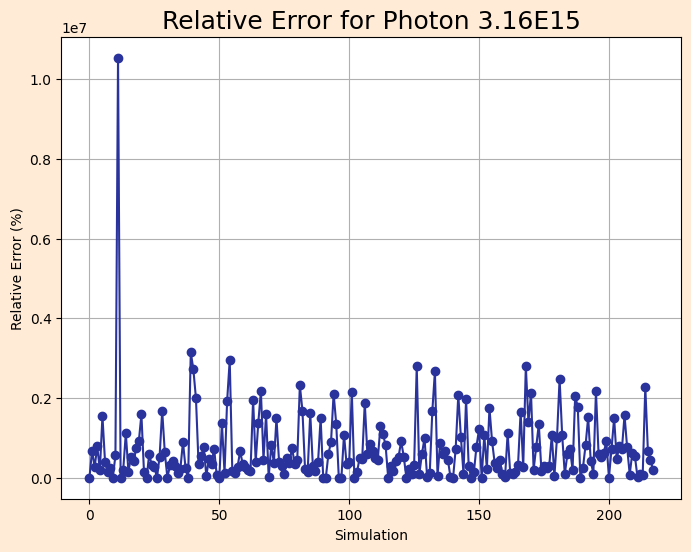

In [30]:
fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
plt.plot(erro_relativo, marker='o', linestyle='-', color='#29339B')
plt.xlabel('Simulation')
plt.ylabel('Relative Error (%)')
plt.title('Relative Error for ' + str(name), size = 18)
plt.grid(True)
plt.show()

In [26]:
df3.filter(pl.col("Relative_error") < 50)

E,Relative_error,Absolute_error
f64,f64,f64
3.0755e15,2.67441,8.4511e13
4.1228e15,30.467895,9.6279e14
4.0701e15,28.801837,9.1014e14
4.1228e15,30.467895,9.6279e14


[1.35649802e-13 3.84310014e-03]
[4.62103782 5.21341874 5.8065416 ]


C:\Users\Lucas\AppData\Local\Temp\ipykernel_6192\1866268954.py:24: RuntimeWarning: invalid value encountered in log10
  return np.log10(k*x**p)
C:\Users\Lucas\AppData\Local\Temp\ipykernel_6192\1866268954.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'


logC,logE_S,logE_R,error (%)
f64,f64,f64,f64
4.619928,14.0,13.999064,0.006689
5.215638,14.499687,14.501559,0.012908
5.805433,15.0,14.999065,0.006235


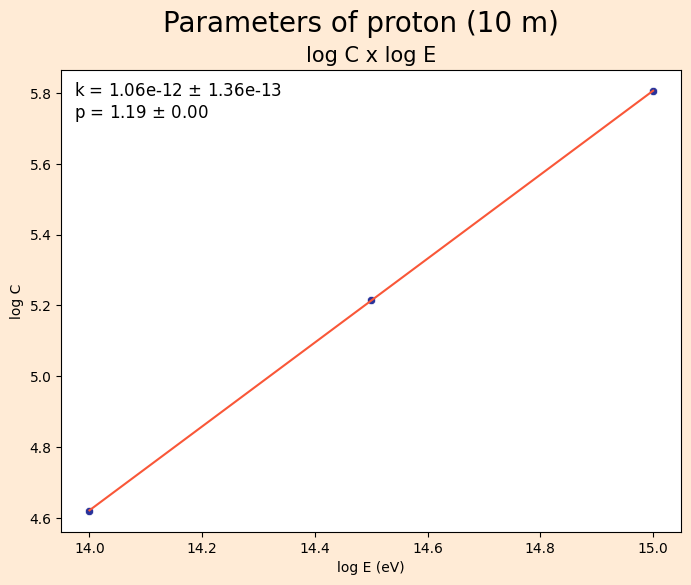

In [15]:
# Fit do próton
from scipy.optimize import curve_fit

C = [4.168e+04, 1.643e+05, 6.389e+05]
E = [1E14, 3.16E14, 1E15]

logC = np.log10(C)
logE = np.log10(E)


fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
fig.suptitle('Parameters of proton (10 m)', size = 20)
#fig.tight_layout()


ax.set_title('log C x log E', size = 15)
ax.set_xlabel('log E (eV)')
ax.set_ylabel('log C')
ax.set_facecolor('white')


#Fit
def power(x, k, p):
    return np.log10(k*x**p)

initial_guess = [1,1]

coefficients_proton, cov = curve_fit(power, E, np.log10(C), p0=initial_guess)

inc = np.sqrt(np.diag(cov))
print(np.sqrt(np.diag(cov)))

print(power(E,*coefficients_proton))

ax.plot(logE, power(E,*coefficients_proton), color = '#F95738')
sns.scatterplot(x = logE, y = logC, color = '#29339B', ax = ax)

ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'
          .format(coefficients_proton[0],inc[0],coefficients_proton[1],inc[1]),
          title_fontsize = 12,facecolor = 'white', frameon = False)


logE_0_array = ((np.log10(C/coefficients_proton[0]))/coefficients_proton[1])

logE_0 = logE_0_array.tolist()

data = {
    'logC':logC,
    'logE_S':logE,
    'logE_R':logE_0
}

df = pl.DataFrame(data)

df = df.with_columns(
        abs((((pl.col('logE_R')-pl.col('logE_S'))/pl.col('logE_S'))*100)).alias('error (%)')
)
df

[2.12202004e-06 2.38934361e-01]
[4.27281222 4.66000189 5.04767649]


C:\Users\Lucas\AppData\Local\Temp\ipykernel_6192\492269532.py:24: RuntimeWarning: invalid value encountered in log10
  return np.log10(k*x**p)
C:\Users\Lucas\AppData\Local\Temp\ipykernel_6192\492269532.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'


logC,logE_S,logE_R,error (%)
f64,f64,f64,f64
4.34183,14.0,14.089071,0.636221
4.522053,14.499687,14.321657,1.22782
5.116608,15.0,15.088959,0.593061


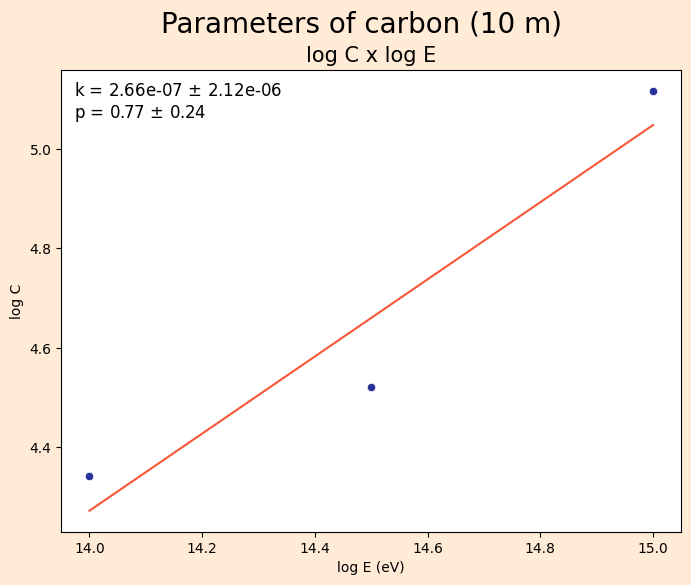

In [16]:
# Fit do carbono
from scipy.optimize import curve_fit

C = [2.197e+04, 3.327e+04, 1.308e+05]
E = [1E14, 3.16E14, 1E15]

logC = np.log10(C)
logE = np.log10(E)


fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
fig.suptitle('Parameters of carbon (10 m)', size = 20)
#fig.tight_layout()


ax.set_title('log C x log E', size = 15)
ax.set_xlabel('log E (eV)')
ax.set_ylabel('log C')
ax.set_facecolor('white')


#Fit
def power(x, k, p):
    return np.log10(k*x**p)

initial_guess = [1,1]

coefficients_carbon, cov = curve_fit(power, E, np.log10(C), p0=initial_guess)

inc = np.sqrt(np.diag(cov))
print(np.sqrt(np.diag(cov)))

print(power(E,*coefficients_carbon))

ax.plot(logE, power(E,*coefficients_carbon), color = '#F95738')
sns.scatterplot(x = logE, y = logC, color = '#29339B', ax = ax)

ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'
          .format(coefficients_carbon[0],inc[0],coefficients_carbon[1],inc[1]),
          title_fontsize = 12,facecolor = 'white', frameon = False)


logE_0_array = ((np.log10(C/coefficients_carbon[0]))/coefficients_carbon[1])

logE_0 = logE_0_array.tolist()

data = {
    'logC':logC,
    'logE_S':logE,
    'logE_R':logE_0
}

df = pl.DataFrame(data)

df = df.with_columns(
        abs((((pl.col('logE_R')-pl.col('logE_S'))/pl.col('logE_S'))*100)).alias('error (%)')
)
df

[6.16995911e-16 8.87504152e-02]
[3.71289752 4.40512596 5.09822138]


C:\Users\Lucas\AppData\Local\Temp\ipykernel_6192\4078106409.py:24: RuntimeWarning: invalid value encountered in log10
  return np.log10(k*x**p)
C:\Users\Lucas\AppData\Local\Temp\ipykernel_6192\4078106409.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'


logC,logE_S,logE_R,error (%)
f64,f64,f64,f64
3.687261,14.0,13.981494,0.132182
4.456366,14.499687,14.536675,0.255094
5.072617,15.0,14.981518,0.123215


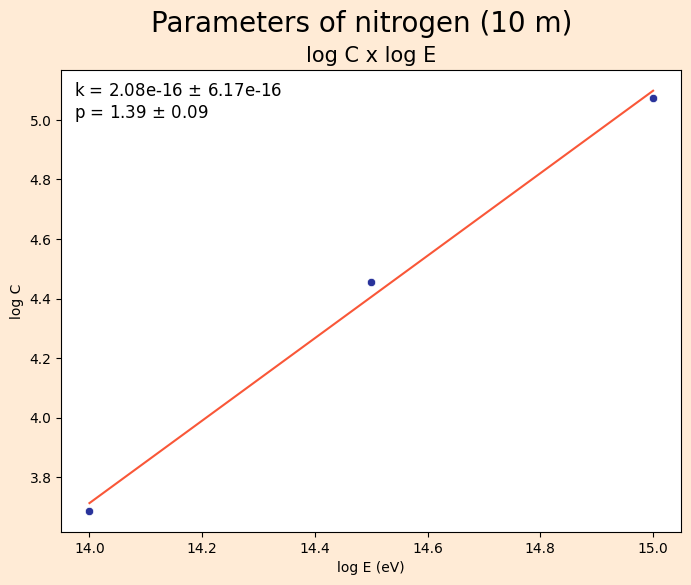

In [17]:
# Fit do nitrogênio
from scipy.optimize import curve_fit

C = [4867, 2.86e+04, 1.182e+05]
E = [1E14, 3.16E14, 1E15]

logC = np.log10(C)
logE = np.log10(E)


fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
fig.suptitle('Parameters of nitrogen (10 m)', size = 20)
#fig.tight_layout()


ax.set_title('log C x log E', size = 15)
ax.set_xlabel('log E (eV)')
ax.set_ylabel('log C')
ax.set_facecolor('white')


#Fit
def power(x, k, p):
    return np.log10(k*x**p)

initial_guess = [1,1]

coefficients_nitrogen, cov = curve_fit(power, E, np.log10(C), p0=initial_guess)

inc = np.sqrt(np.diag(cov))
print(np.sqrt(np.diag(cov)))

print(power(E,*coefficients_nitrogen))

ax.plot(logE, power(E,*coefficients_nitrogen), color = '#F95738')
sns.scatterplot(x = logE, y = logC, color = '#29339B', ax = ax)

ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'
          .format(coefficients_nitrogen[0],inc[0],coefficients_nitrogen[1],inc[1]),
          title_fontsize = 12,facecolor = 'white', frameon = False)


logE_0_array = ((np.log10(C/coefficients_nitrogen[0]))/coefficients_nitrogen[1])

logE_0 = logE_0_array.tolist()

data = {
    'logC':logC,
    'logE_S':logE,
    'logE_R':logE_0
}

df = pl.DataFrame(data)

df = df.with_columns(
        abs((((pl.col('logE_R')-pl.col('logE_S'))/pl.col('logE_S'))*100)).alias('error (%)')
)
df

[3.30510011e-16 2.46194254e-02]
[3.7298276  4.41245988 5.09594713]


C:\Users\Lucas\AppData\Local\Temp\ipykernel_6192\3567477852.py:24: RuntimeWarning: invalid value encountered in log10
  return np.log10(k*x**p)
C:\Users\Lucas\AppData\Local\Temp\ipykernel_6192\3567477852.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'


logC,logE_S,logE_R,error (%)
f64,f64,f64,f64
3.722716,14.0,13.994794,0.037183
4.426674,14.499687,14.510092,0.071758
5.088845,15.0,14.994801,0.034661


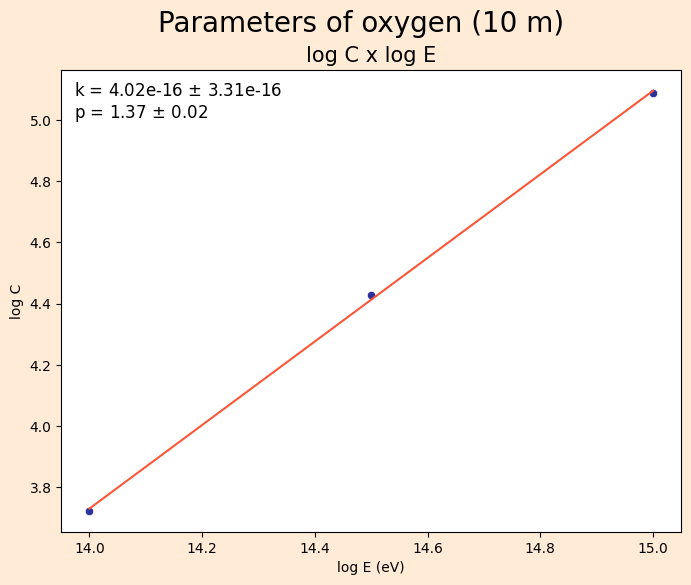

In [18]:
# Fit do oxigênio
from scipy.optimize import curve_fit

C = [5281, 2.671e+04, 1.227e+05]
E = [1E14, 3.16E14, 1E15]

logC = np.log10(C)
logE = np.log10(E)


fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
fig.suptitle('Parameters of oxygen (10 m)', size = 20)
#fig.tight_layout()


ax.set_title('log C x log E', size = 15)
ax.set_xlabel('log E (eV)')
ax.set_ylabel('log C')
ax.set_facecolor('white')


#Fit
def power(x, k, p):
    return np.log10(k*x**p)

initial_guess = [1,1]

coefficients_oxygen, cov = curve_fit(power, E, np.log10(C), p0=initial_guess)

inc = np.sqrt(np.diag(cov))
print(np.sqrt(np.diag(cov)))

print(power(E,*coefficients_oxygen))

ax.plot(logE, power(E,*coefficients_oxygen), color = '#F95738')
sns.scatterplot(x = logE, y = logC, color = '#29339B', ax = ax)

ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'
          .format(coefficients_oxygen[0],inc[0],coefficients_oxygen[1],inc[1]),
          title_fontsize = 12,facecolor = 'white', frameon = False)


logE_0_array = ((np.log10(C/coefficients_oxygen[0]))/coefficients_oxygen[1])

logE_0 = logE_0_array.tolist()

data = {
    'logC':logC,
    'logE_S':logE,
    'logE_R':logE_0
}

df = pl.DataFrame(data)

df = df.with_columns(
        abs((((pl.col('logE_R')-pl.col('logE_S'))/pl.col('logE_S'))*100)).alias('error (%)')
)
df

[2.35395954e-15 3.98679384e-02]
[4.06730312 4.73902106 5.4115803 ]


C:\Users\Lucas\AppData\Local\Temp\ipykernel_6192\3654635265.py:24: RuntimeWarning: invalid value encountered in log10
  return np.log10(k*x**p)
C:\Users\Lucas\AppData\Local\Temp\ipykernel_6192\3654635265.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'


logC,logE_S,logE_R,error (%)
f64,f64,f64,f64
4.078819,14.0,14.008567,0.061191
4.716003,14.499687,14.482564,0.11809
5.423082,15.0,15.008556,0.05704


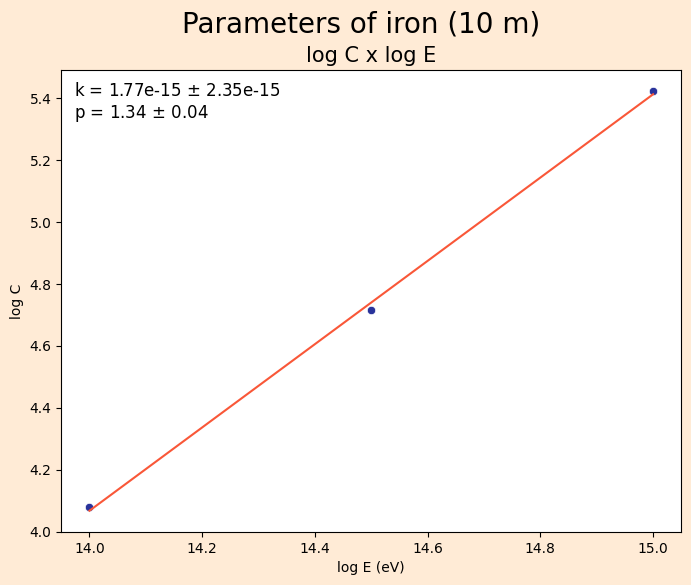

In [19]:
# Fit do ferro
from scipy.optimize import curve_fit

C = [1.199e+04, 5.2e+04, 2.649e+05]
E = [1E14, 3.16E14, 1E15]

logC = np.log10(C)
logE = np.log10(E)


fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
fig.suptitle('Parameters of iron (10 m)', size = 20)
#fig.tight_layout()


ax.set_title('log C x log E', size = 15)
ax.set_xlabel('log E (eV)')
ax.set_ylabel('log C')
ax.set_facecolor('white')


#Fit
def power(x, k, p):
    return np.log10(k*x**p)

initial_guess = [1,1]

coefficients_iron, cov = curve_fit(power, E, np.log10(C), p0=initial_guess)

inc = np.sqrt(np.diag(cov))
print(np.sqrt(np.diag(cov)))

print(power(E,*coefficients_iron))

ax.plot(logE, power(E,*coefficients_iron), color = '#F95738')
sns.scatterplot(x = logE, y = logC, color = '#29339B', ax = ax)

ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'
          .format(coefficients_iron[0],inc[0],coefficients_iron[1],inc[1]),
          title_fontsize = 12,facecolor = 'white', frameon = False)


logE_0_array = ((np.log10(C/coefficients_iron[0]))/coefficients_iron[1])

logE_0 = logE_0_array.tolist()

data = {
    'logC':logC,
    'logE_S':logE,
    'logE_R':logE_0
}

df = pl.DataFrame(data)

df = df.with_columns(
        abs((((pl.col('logE_R')-pl.col('logE_S'))/pl.col('logE_S'))*100)).alias('error (%)')
)
df

In [20]:
# Reconstrução da energia

E_real = [1E14, 3.16E14, 1E15]
r0 = 7800

# Parâmetros fóton

k_photon = coefficients_photon[0] 
p_photon = coefficients_photon[1] 
c_photon = [476.7,2411,1.293e+04] 
E_photon = []


for i in range(len(c_photon)):
    E = (c_photon[i]/k_photon)**(1/p_photon)
    E_photon.append(E)


# Parâmetros próton

k_proton = coefficients_proton[0]
p_proton = coefficients_proton[1]
c_proton = [566.7,2740,1.248e+04]
E_proton = []

for i in range(len(c_photon)):
    E = (c_proton[i]/k_proton)**(1/p_proton)
    E_proton.append(E)

# Parâmetros carbono

k_carbon = coefficients_carbon[0]
p_carbon = coefficients_carbon[1]
c_carbon = [158.1,861,6107]
E_carbon = []

for i in range(len(c_photon)):
    E = (c_carbon[i]/k_carbon)**(1/p_carbon)
    E_carbon.append(E)

# Parâmetros nitrogênio

k_nitrogen = coefficients_nitrogen[0]
p_nitrogen = coefficients_nitrogen[1]
c_nitrogen = [130.5,939.6,4829]
E_nitrogen = []

for i in range(len(c_photon)):
    E = (c_nitrogen[i]/k_nitrogen)**(1/p_nitrogen)
    E_nitrogen.append(E)

# Parâmetros oxigênio

k_oxygen = coefficients_oxygen[0]
p_oxygen = coefficients_oxygen[1]
c_oxygen = [132.3,775.1,5115]
E_oxygen = []

for i in range(len(c_photon)):
    E = (c_oxygen[i]/k_oxygen)**(1/p_oxygen)
    E_oxygen.append(E)

# Parâmetros ferro

k_iron = coefficients_iron[0]
p_iron = coefficients_iron[1]
c_iron = [36.59,294.4,2545]
E_iron = []

for i in range(len(c_iron)):
    E = (c_iron[i]/k_iron)**(1/p_iron)
    E_iron.append(E)
    


data = {
    'E':E_real,
    'E_photon':E_photon,
    'E_proton':E_proton,
    'E_carbon':E_carbon,
    'E_nitrogen':E_nitrogen,
    'E_oxygen':E_oxygen,
    'E_iron':E_iron
}

df = pl.DataFrame(data)
df

E,E_photon,E_proton,E_carbon,E_nitrogen,E_oxygen,E_iron
f64,f64,f64,f64,f64,f64,f64
1.0000e14,5.3050e12,2.6581e12,2.1065e11,7.0306e12,6.6489e12,1.3719e12
3.1600e14,1.7443e13,1.0043e13,1.8771e12,2.9232e13,2.4254e13,6.4712e12
1.0000e15,5.9873e13,3.6083e13,2.3525e13,9.5288e13,9.6525e13,3.2198e13


[Text(0.5, 1.0, 'Energy relative diviation $\\Delta$E/E')]

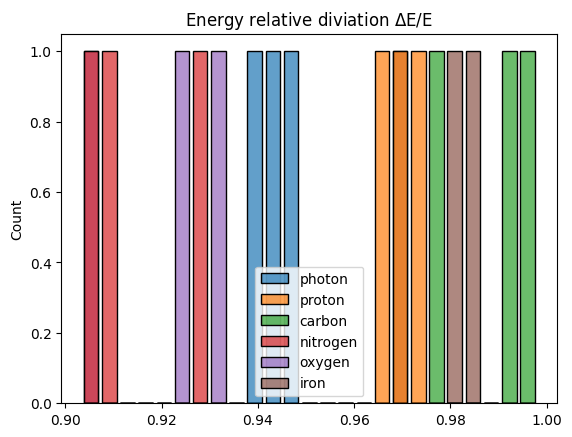

In [21]:
DeltaE_photon = []
DeltaE_proton = []
DeltaE_carbon = []
DeltaE_nitrogen = []
DeltaE_oxygen = []
DeltaE_iron = []

for i in range(len(E_real)):
    aux = (E_real[i] - E_photon[i])/E_real[i]
    aux2 = (E_real[i] - E_proton[i])/E_real[i]
    aux3 = (E_real[i] - E_carbon[i])/E_real[i]
    aux4 = (E_real[i] - E_nitrogen[i])/E_real[i]
    aux5 = (E_real[i] - E_oxygen[i])/E_real[i]
    aux6 = (E_real[i] - E_iron[i])/E_real[i]
    DeltaE_photon.append(aux)
    DeltaE_proton.append(aux2)
    DeltaE_carbon.append(aux3)
    DeltaE_nitrogen.append(aux4)
    DeltaE_oxygen.append(aux5)
    DeltaE_iron.append(aux6)

data = {
    'photon':DeltaE_photon,
    'proton':DeltaE_proton,
    'carbon':DeltaE_carbon,
    'nitrogen':DeltaE_nitrogen,
    'oxygen':DeltaE_oxygen,
    'iron':DeltaE_iron
}

sns.histplot(data=data, bins= 25, shrink=0.8, alpha = 0.7).set(title = 'Energy relative diviation $\Delta$E/E')



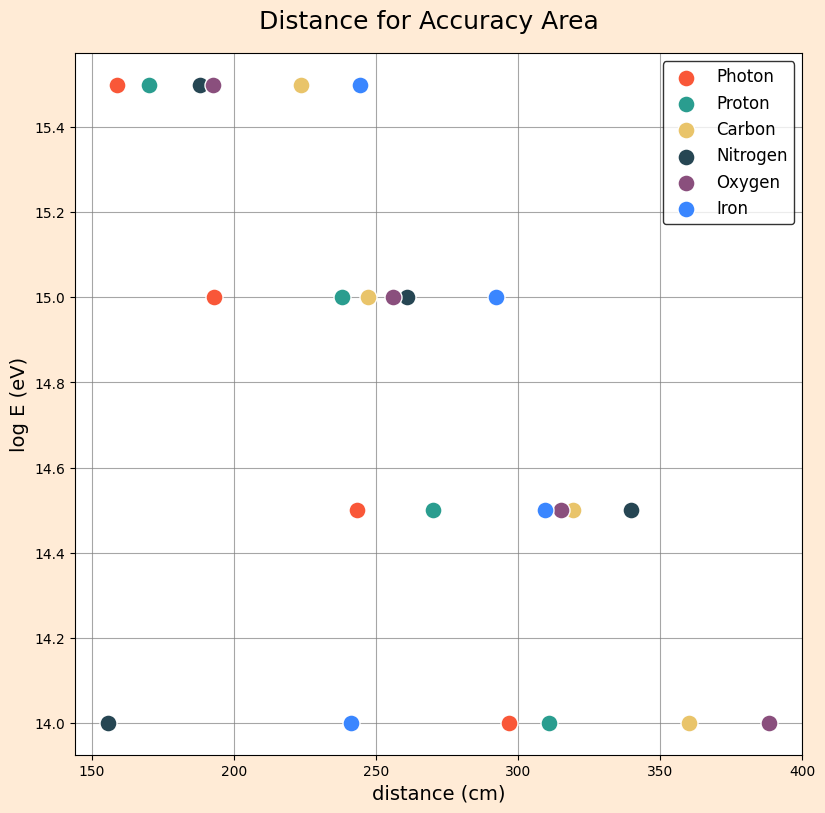

In [22]:
energy1 = [1E14, 3.16E14, 1E15, 3.16E15]
energy = np.log10(energy1)

photon = [296.76, 243.37, 192.98, 158.92]
proton = [310.83, 269.99, 238.02, 169.90]
carbon = [360.12, 319.32, 246.98, 223.55]
nitrogen = [155.69, 339.63, 260.88, 187.82]
oxygen = [388.38, 315.07, 256.06, 192.68]
iron = [241.06, 309.35, 292.14, 244.16]

fig, ax = plt.subplots(1, 1, figsize=(8, 8), facecolor='#FFEBD6')
fig.suptitle('Distance for Accuracy Area', size=18)
fig.tight_layout()

ax.set_axisbelow(True)
ax.yaxis.grid(color='gray', linestyle='-', alpha=0.7)
ax.xaxis.grid(color='gray', linestyle='-', alpha=0.7)

sns.scatterplot(x=photon, y=energy, ax=ax, color='#F95738', s=150, label='Photon')
sns.scatterplot(x=proton, y=energy, ax=ax, color='#2A9D8F', s=150, label='Proton')
sns.scatterplot(x=carbon, y=energy, ax=ax, color='#E9C46A', s=150, label='Carbon')
sns.scatterplot(x=nitrogen, y=energy, ax=ax, color='#264653', s=150, label='Nitrogen')
sns.scatterplot(x=oxygen, y=energy, ax=ax, color='#8A4F7D', s=150, label='Oxygen')
sns.scatterplot(x=iron, y=energy, ax=ax, color='#3A86FF', s=150, label='Iron')

ax.set_xlabel('distance (cm)', size=14)
ax.set_ylabel('log E (eV)', size=14)

ax.legend(edgecolor='black', fontsize=12, loc='upper right')

plt.show()


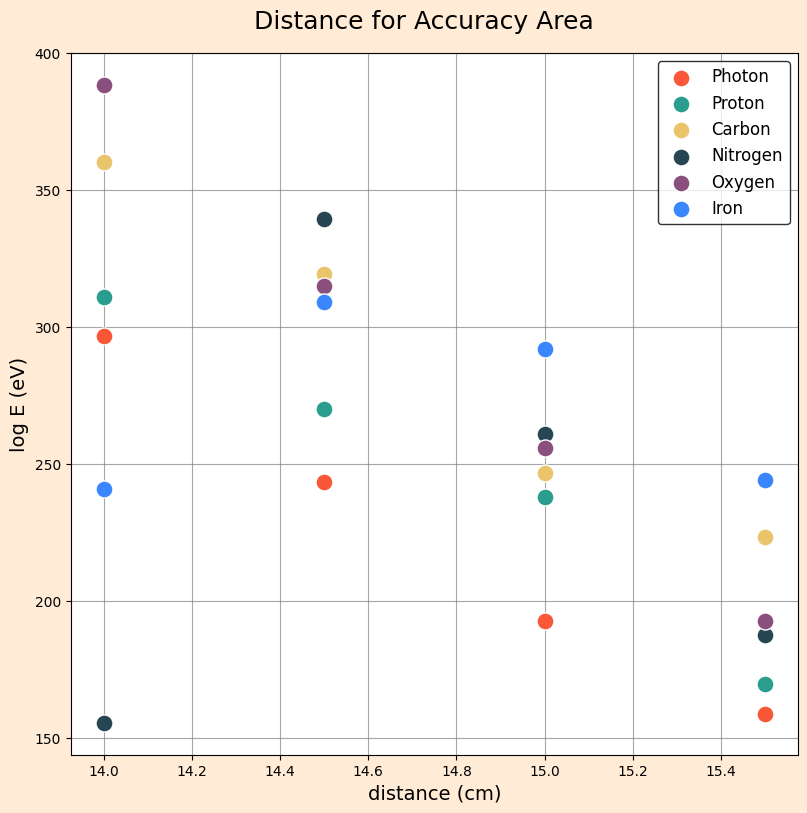

In [23]:
energy1 = [1E14, 3.16E14, 1E15, 3.16E15]
energy = np.log10(energy1)

photon = [296.76, 243.37, 192.98, 158.92]
proton = [310.83, 269.99, 238.02, 169.90]
carbon = [360.12, 319.32, 246.98, 223.55]
nitrogen = [155.69, 339.63, 260.88, 187.82]
oxygen = [388.38, 315.07, 256.06, 192.68]
iron = [241.06, 309.35, 292.14, 244.16]

fig, ax = plt.subplots(1, 1, figsize=(8, 8), facecolor='#FFEBD6')
fig.suptitle('Distance for Accuracy Area', size=18)
fig.tight_layout()

ax.set_axisbelow(True)
ax.yaxis.grid(color='gray', linestyle='-', alpha=0.7)
ax.xaxis.grid(color='gray', linestyle='-', alpha=0.7)

sns.scatterplot(y=photon, x=energy, ax=ax, color='#F95738', s=150, label='Photon')
sns.scatterplot(y=proton, x=energy, ax=ax, color='#2A9D8F', s=150, label='Proton')
sns.scatterplot(y=carbon, x=energy, ax=ax, color='#E9C46A', s=150, label='Carbon')
sns.scatterplot(y=nitrogen, x=energy, ax=ax, color='#264653', s=150, label='Nitrogen')
sns.scatterplot(y=oxygen, x=energy, ax=ax, color='#8A4F7D', s=150, label='Oxygen')
sns.scatterplot(y=iron, x=energy, ax=ax, color='#3A86FF', s=150, label='Iron')

ax.set_xlabel('distance (cm)', size=14)
ax.set_ylabel('log E (eV)', size=14)

ax.legend(edgecolor='black', fontsize=12, loc='upper right')

plt.show()


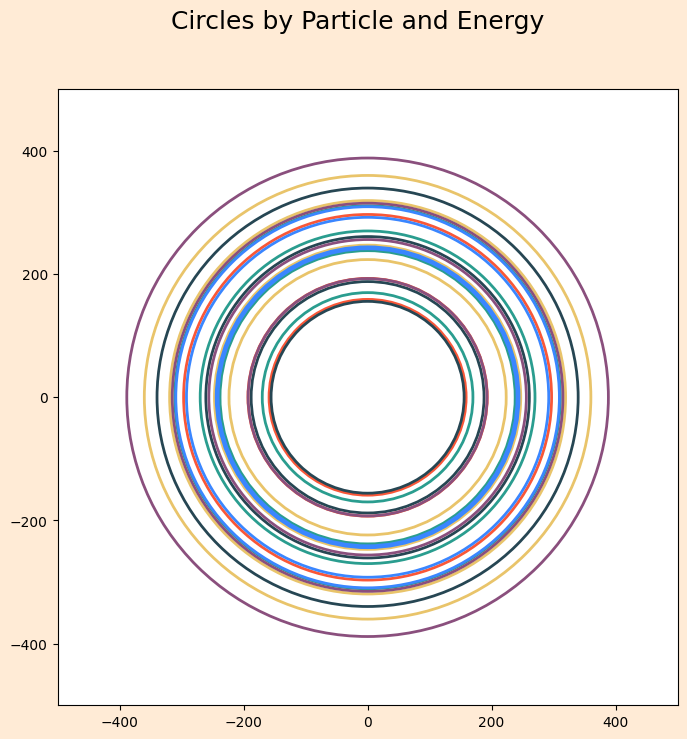

In [24]:
fig, ax = plt.subplots(1,1,figsize=(8, 8), facecolor='#FFEBD6')
fig.suptitle('Circles by Particle and Energy', size=18)

for i, e in enumerate(energy):  
    radius = photon[i]  
    circle = plt.Circle((0, 0), radius=radius, color='#F95738', fill = False, linewidth = 2, label=f'{e:.2E} eV' if i == 0 else None)
    ax.add_patch(circle)

for i, e in enumerate(energy):  
    radius = proton[i]  
    circle = plt.Circle((0, 0), radius=radius, color='#2A9D8F', fill = False, linewidth = 2, label=f'{e:.2E} eV' if i == 0 else None)
    ax.add_patch(circle)

for i, e in enumerate(energy):  
    radius = carbon[i]  
    circle = plt.Circle((0, 0), radius=radius, color='#E9C46A', fill = False, linewidth = 2, label=f'{e:.2E} eV' if i == 0 else None)
    ax.add_patch(circle)

for i, e in enumerate(energy):  
    radius = nitrogen[i]  
    circle = plt.Circle((0, 0), radius=radius, color='#264653', fill = False, linewidth = 2, label=f'{e:.2E} eV' if i == 0 else None)
    ax.add_patch(circle)

for i, e in enumerate(energy):  
    radius = oxygen[i]  
    circle = plt.Circle((0, 0), radius=radius, color='#8A4F7D', fill = False, linewidth = 2, label=f'{e:.2E} eV' if i == 0 else None)
    ax.add_patch(circle)


for i, e in enumerate(energy):  
    radius = iron[i]  
    circle = plt.Circle((0, 0), radius=radius, color='#3A86FF', fill = False, linewidth = 2, label=f'{e:.2E} eV' if i == 0 else None)
    ax.add_patch(circle)

plt.xlim([-500,500])
plt.ylim([-500,500])

plt.show()